# AI4I 2020 — Exploratory Data Analysis

## Objective
Understand the dataset, assess data quality, and establish a
baseline for a simulated maintenance decision.

## Dataset
AI4I 2020 Predictive Maintenance Dataset — UCI Machine Learning Repository.

- Source: https://doi.org/10.24432/C5HS5C
- License: CC BY 4.0
- Target: `Machine failure`

The dataset is synthetic. The target describes a current failure
state; it does not establish a future prediction horizon.

## 1. Load and inspect the data

Load the raw dataset without modifying it, preview the observations,
and inspect column types and missing-value counts.

In [1]:
from pathlib import Path

import pandas as pd

data_path = Path("../data/raw/ai4i2020.csv")

df = pd.read_csv(data_path, encoding="utf-8-sig")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
print("Dimensions :", df.shape)
df.info()

Dimensions : (10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float6

### Observations

- The dataset contains 10,000 rows and 14 columns.
- Pandas reports no missing values.
- Column types appear consistent with their intended roles.
- Value ranges and label consistency still need to be checked.

## 2. Target distribution

Measure the proportion of failure observations to assess class
imbalance and understand the limitations of accuracy.

In [3]:
target_counts = df["Machine failure"].value_counts().sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": 100 * target_counts / len(df),
})

target_summary.index.name = "machine_failure"
target_summary

,count,percentage
machine_failure,,
0,9661,96.61
1,339,3.39


## 3. Simulated business baseline

The baseline always predicts no failure and triggers no intervention.

We assume the following hypothetical costs:

- Missed failure: €10,000.
- Maintenance intervention: €1,000, whether justified or unnecessary.
- No intervention when no failure occurs: €0.

The scenario assumes that an intervention on a failure case avoids
the failure cost entirely. This assumption is not validated by AI4I.

Business cost = 10,000 × FN + 1,000 × (TP + FP).

For this baseline, no interventions occur, so:
Baseline cost = 10,000 × number of failure observations.

These full-dataset calculations are descriptive, not final test results.

In [4]:
# Hypothetical costs for our simulated maintenance scenario.
COST_MISSED_FAILURE = 10_000
COST_INTERVENTION = 1_000

n_observations = len(df)
n_failures = int(df["Machine failure"].eq(1).sum())
n_no_failure = int(df["Machine failure"].eq(0).sum())

baseline_accuracy = n_no_failure / n_observations
baseline_total_cost = COST_MISSED_FAILURE * n_failures
baseline_cost_per_observation = baseline_total_cost / n_observations

print(f"Baseline accuracy: {baseline_accuracy:.2%}")
print(f"Missed failures: {n_failures}")
print(f"Simulated total cost: €{baseline_total_cost:,.0f}")
print(f"Simulated cost per observation: €{baseline_cost_per_observation:,.2f}")

Baseline accuracy: 96.61%
Missed failures: 339
Simulated total cost: €3,390,000
Simulated cost per observation: €339.00


### Baseline interpretation

The no-intervention baseline achieves 96.61% accuracy but misses
all 339 failure observations, resulting in 0% failure recall.

Under our hypothetical cost assumptions:
- Total simulated cost: €3,390,000.
- Mean simulated cost: €339 per observation.

High accuracy alone therefore does not demonstrate useful failure
detection. Future models will be evaluated against this baseline
on the same held-out test set.

These figures describe a simulated scenario, not measured industrial losses.

## 4. Failure-label consistency

Compare the overall failure target with the five failure-mode indicators.

Check for:
- An active failure mode with no overall failure.
- An overall failure with no active failure mode.

Discrepancies will be documented without modifying the raw labels.

In [5]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# Check that all failure labels contain only 0 or 1.
label_columns = ["Machine failure"] + failure_modes
invalid_labels = (~df[label_columns].isin([0, 1])).sum()

print("Invalid binary labels per column:")
print(invalid_labels)

# Compare individual failure modes with the overall target.
has_failure_mode = df[failure_modes].eq(1).any(axis=1)
has_machine_failure = df["Machine failure"].eq(1)

mode_without_failure = has_failure_mode & ~has_machine_failure
failure_without_mode = has_machine_failure & ~has_failure_mode

print("\nActive mode without overall failure:",
      mode_without_failure.sum())
print("Overall failure without active mode:",
      failure_without_mode.sum())

Invalid binary labels per column:
Machine failure    0
TWF                0
HDF                0
PWF                0
OSF                0
RNF                0
dtype: int64

Active mode without overall failure: 18
Overall failure without active mode: 9


### Findings and decision

All six label columns contain only binary values (0 or 1).

However, 27 observations show discrepancies:
- 18 have an active failure mode but `Machine failure = 0`.
- 9 have `Machine failure = 1` but no active failure mode.

These discrepancies affect 0.27% of observations. The available
information does not establish which annotation is correct.

We retain all observations and use `Machine failure` as the supplied
target, without reconstructing it from the individual failure modes.

Failure-mode indicators will be excluded from model inputs to avoid
target leakage. These discrepancies remain a documented dataset limitation.

## 5. Sensor ranges and product categories

Inspect numeric feature distributions and product categories
to identify potential data-quality issues.

Observed ranges describe this dataset; they should not automatically
be treated as operating limits for future production data.

In [6]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

sensor_summary = df[numeric_features].describe().T
sensor_summary

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


### Sensor-range observations

- All five numeric features contain 10,000 non-missing values.
- Temperatures, rotational speed, and torque are positive;
  tool wear is non-negative.
- Mean process temperature is approximately 10 K above mean air
  temperature. This does not establish the relationship for every row.
- Maximum rotational speed is well above the upper quartile and
  warrants further inspection.

No observations are removed at this stage. Unusual measurements
may reflect valid operating or failure conditions, and observed
minimums and maximums are not established engineering limits.

In [7]:
type_counts = df["Type"].value_counts(dropna=False).sort_index()

type_summary = pd.DataFrame({
    "count": type_counts,
    "percentage": 100 * type_counts / len(df),
})

type_summary.index.name = "product_type"
type_summary

,count,percentage
product_type,,
H,1003,10.03
L,6000,60.00
M,2997,29.97


### Product-category observations

`Type` represents product quality: L (low), M (medium), and H (high).

Only the three expected categories are present:
- L: 60.00%
- M: 29.97%
- H: 10.03%

These proportions describe product representation, not failure rates.

## 6. Failure rate by product category

Compare failure rates within each product category.

Because categories have different sample sizes, compare the proportion
of failures rather than raw failure counts. These descriptive
associations do not establish causation.

In [8]:
failure_by_type = (
    df.groupby("Type")["Machine failure"]
    .agg(
        observations="size",
        failures="sum",
        failure_rate="mean",
    )
)

failure_by_type["failure_rate_percent"] = (
    100 * failure_by_type["failure_rate"]
)

failure_by_type[
    ["observations", "failures", "failure_rate_percent"]
].round(2)

,observations,failures,failure_rate_percent
Type,,,
H,1003,21,2.09
L,6000,235,3.92
M,2997,83,2.77


### Interpretation

Observed failure rates differ across product categories:
- H: 2.09% (21 failures / 1,003 observations).
- M: 2.77% (83 / 2,997).
- L: 3.92% (235 / 6,000).

The L–H difference is approximately 1.83 percentage points.

This association suggests that product type may be useful for prediction.
It does not establish causation or demonstrate predictive value beyond
the sensor measurements. That contribution will be assessed during
model validation.

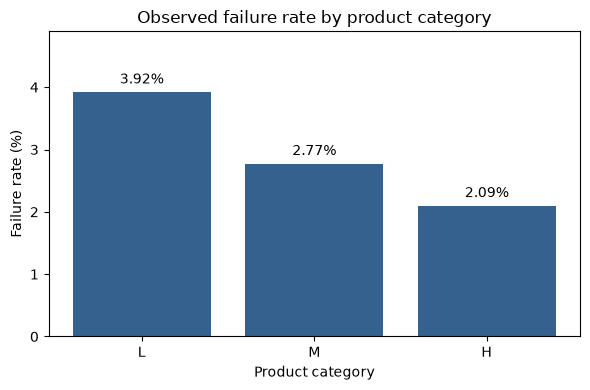

In [9]:
import matplotlib.pyplot as plt

rates = failure_by_type["failure_rate_percent"].reindex(["L", "M", "H"])

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(rates.index, rates.values, color="#35618f")

ax.bar_label(bars, fmt="%.2f%%", padding=4)
ax.set(
    title="Observed failure rate by product category",
    xlabel="Product category",
    ylabel="Failure rate (%)",
    ylim=(0, rates.max() * 1.25),
)

fig.tight_layout()
plt.show()

## 7. Reproducible train / validation / test split

We allocate:
- 60% of observations to training.
- 20% to model selection and decision-threshold tuning.
- 20% to final testing.

Splits are stratified by `Machine failure` to approximately preserve
failure prevalence. A fixed random seed makes the split reproducible
for the same input data and environment.

Preliminary full-dataset exploration has already been performed.
From this point onward, further exploratory decisions will use training
data, and test performance will not guide model or threshold selection.

This random split is an in-distribution benchmark. Sequential
dependencies may make its results optimistic relative to future-period
deployment; it does not establish temporal generalization.

In [10]:
from predictive_maintenance.data import split_dataset

TARGET = "Machine failure"
RANDOM_STATE = 42

train_df, val_df, test_df = split_dataset(
    df,
    random_state=RANDOM_STATE,
)

In [11]:
split_summary = pd.DataFrame({
    "train": {
        "observations": len(train_df),
        "failures": int(train_df[TARGET].sum()),
        "failure_rate_percent": 100 * train_df[TARGET].mean(),
    },
    "validation": {
        "observations": len(val_df),
        "failures": int(val_df[TARGET].sum()),
        "failure_rate_percent": 100 * val_df[TARGET].mean(),
    },
    "test": {
        "observations": len(test_df),
        "failures": int(test_df[TARGET].sum()),
        "failure_rate_percent": 100 * test_df[TARGET].mean(),
    },
}).T

split_summary.round(2)

,observations,failures,failure_rate_percent
train,6000.0,203.0,3.38
validation,2000.0,68.0,3.40
test,2000.0,68.0,3.40


### Split integrity checks

Verify that each observation belongs to exactly one split and
that all original observations are retained.

`UDI` is used only for traceability, not as a model input.

In [12]:
# Each source observation must have a unique, non-missing identifier.
assert df["UDI"].notna().all(), "Missing observation identifiers."
assert df["UDI"].is_unique, "Duplicate observation identifiers."

train_ids = set(train_df["UDI"])
val_ids = set(val_df["UDI"])
test_ids = set(test_df["UDI"])

# No observation may appear in more than one split.
assert train_ids.isdisjoint(val_ids), "Train/validation overlap."
assert train_ids.isdisjoint(test_ids), "Train/test overlap."
assert val_ids.isdisjoint(test_ids), "Validation/test overlap."

# Every original observation must be retained exactly once.
assert train_ids | val_ids | test_ids == set(df["UDI"]), (
    "Missing or unexpected observations."
)
assert len(train_df) + len(val_df) + len(test_df) == len(df), (
    "Incorrect total number of observations."
)

print("Split checks passed: no overlap and all observations retained.")

Split checks passed: no overlap and all observations retained.


### Split summary

- Training: 6,000 observations, including 203 failures (3.38%).
- Validation: 2,000 observations, including 68 failures (3.40%).
- Test: 2,000 observations, including 68 failures (3.40%).

The splits share no observation identifiers and collectively retain
all original observations. Failure prevalence is approximately preserved.

This split will remain fixed for subsequent experiments.

The split is implemented in `predictive_maintenance.data.split_dataset`.
This notebook calls the reusable function and checks its output.

### Raw-data validation

Validate required columns, missing values, observation identifiers,
product categories, and binary labels before further processing.

Validation raises an explicit error when a required condition fails.
Known discrepancies between the overall target and failure-mode
indicators are retained and documented separately.

Numeric sensor types and physical constraints are not yet checked.

In [13]:
from predictive_maintenance.data import validate_raw_data

validate_raw_data(df)

print("Raw-data structure and label checks passed.")

Raw-data structure and label checks passed.


Sensor values must be numeric and finite. Temperatures must be strictly
positive in kelvin. Rotational speed, torque, and tool wear must be
non-negative under the conventions used for this dataset.

No upper limits are inferred from the observed dataset ranges.